In [ ]:
import pandas as pd
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

# Download the zip file
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Use BytesIO to handle the zip file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # The Excel file inside the zip is named 'Online Retail.xlsx'
    excel_filename = 'Online Retail.xlsx'

    # Read the Excel file directly from the zip archive's content
    with z.open(excel_filename) as excel_file:
        df = pd.read_excel(excel_file, engine="openpyxl")

df.shape

(541909, 8)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
# Keep only genuine sales: positive quantity and positive price
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# Create the Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Check how many rows we kept
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

df_clean[['InvoiceDate', 'Quantity', 'UnitPrice', 'Revenue']].head()

Original rows: 541909
Cleaned rows: 530104
Rows removed: 11805


,InvoiceDate,Quantity,UnitPrice,Revenue
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


In [ ]:
# Set InvoiceDate as index so we can resample by week
df_weekly = df_clean.set_index('InvoiceDate').resample('W')['Revenue'].sum().reset_index()

# Rename columns to what Prophet expects
df_weekly.columns = ['ds', 'y']

print(df_weekly.shape)
df_weekly.head(10)

(54, 2)


,ds,y
0,2010-12-05,185427.83
1,2010-12-12,329936.81
2,2010-12-19,216012.20
3,2010-12-26,92369.30
4,2011-01-02,0.00
5,2011-01-09,133658.19
6,2011-01-16,193362.04
7,2011-01-23,215533.18
8,2011-01-30,125170.79
9,2011-02-06,125990.68


In [ ]:
df_weekly.tail(5)

,ds,y
49,2011-11-13,370044.97
50,2011-11-20,388622.44
51,2011-11-27,316412.16
52,2011-12-04,324370.83
53,2011-12-11,504309.93


In [ ]:
# Drop the first row (partial week at start) and last row (partial week at end) if it's also partial
df_weekly_trimmed = df_weekly.iloc[1:-1].reset_index(drop=True)

print(df_weekly_trimmed.shape)
df_weekly_trimmed.head()
df_weekly_trimmed.tail()

(52, 2)


,ds,y
47,2011-11-06,301897.83
48,2011-11-13,370044.97
49,2011-11-20,388622.44
50,2011-11-27,316412.16
51,2011-12-04,324370.83


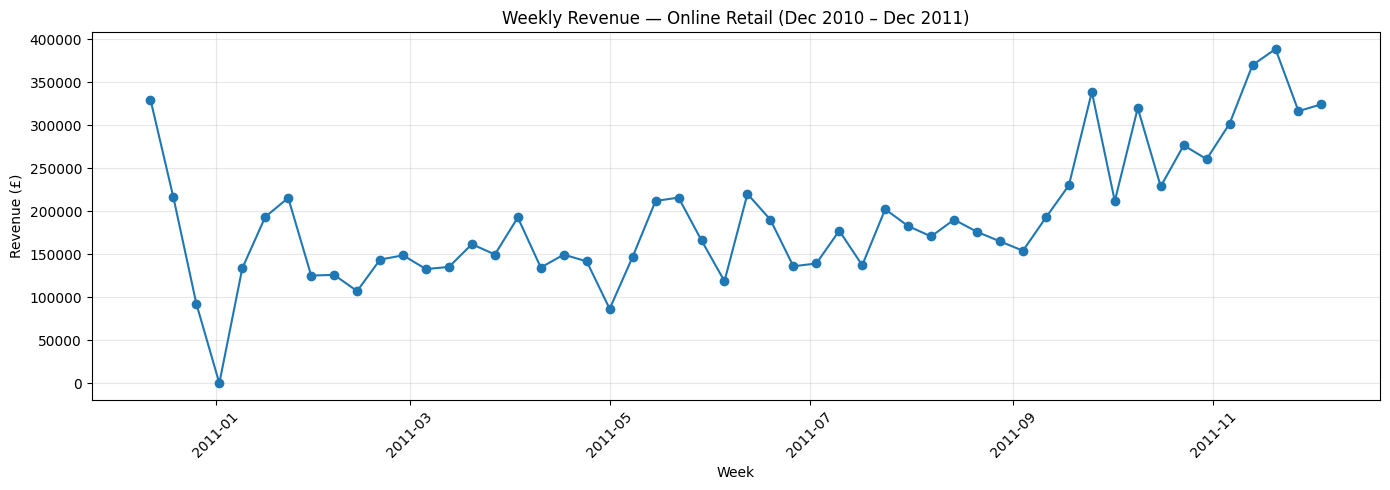

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_weekly_trimmed['ds'], df_weekly_trimmed['y'], marker='o', linewidth=1.5)
plt.title('Weekly Revenue — Online Retail (Dec 2010 – Dec 2011)')
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install prophet -q

In [ ]:
from prophet import Prophet
print("Prophet imported successfully")

Prophet imported successfully


In [ ]:
# Time-based split: last 8 weeks = test, rest = train
train = df_weekly_trimmed.iloc[:-8]
test = df_weekly_trimmed.iloc[-8:]

print(f"Train weeks: {len(train)}  ({train['ds'].min()} to {train['ds'].max()})")
print(f"Test weeks: {len(test)}  ({test['ds'].min()} to {test['ds'].max()})")

Train weeks: 44  (2010-12-12 00:00:00 to 2011-10-09 00:00:00)
Test weeks: 8  (2011-10-16 00:00:00 to 2011-12-04 00:00:00)


In [ ]:
from prophet import Prophet

# Initialize the model
model = Prophet(
    weekly_seasonality=False,   # our data IS weekly already, so this would be meaningless
    yearly_seasonality=False,   # we only have 1 year of data — not enough to detect yearly seasonality reliably
    daily_seasonality=False
)

# Fit on training data
model.fit(train)

In [ ]:
# Create a dataframe of future dates - 8 weeks ahead, matching our test period
future = model.make_future_dataframe(periods=8, freq='W')

# Generate the forecast
forecast = model.predict(future)

# Look at the last 8 rows - these are our future predictions
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(8)

,ds,yhat,yhat_lower,yhat_upper
44,2011-10-16,210462.097554,131782.120920,280125.671953
45,2011-10-23,212234.845526,137720.711995,281135.477292
46,2011-10-30,214007.593497,142521.232901,281110.912436
47,2011-11-06,215780.341469,138957.275854,285073.032292
48,2011-11-13,217553.089440,149460.495444,289000.985356
49,2011-11-20,219325.837412,146447.561976,295459.168033
50,2011-11-27,221098.585383,150391.858707,293972.794590
51,2011-12-04,222871.333355,149668.862219,291085.847932


In [ ]:
comparison = test.reset_index(drop=True).copy()
comparison['yhat'] = forecast['yhat'].tail(8).values
comparison['yhat_lower'] = forecast['yhat_lower'].tail(8).values
comparison['yhat_upper'] = forecast['yhat_upper'].tail(8).values

comparison

,ds,y,yhat,yhat_lower,yhat_upper
0,2011-10-16,228776.18,210462.097554,131782.120920,280125.671953
1,2011-10-23,276656.42,212234.845526,137720.711995,281135.477292
2,2011-10-30,260555.63,214007.593497,142521.232901,281110.912436
3,2011-11-06,301897.83,215780.341469,138957.275854,285073.032292
4,2011-11-13,370044.97,217553.089440,149460.495444,289000.985356
5,2011-11-20,388622.44,219325.837412,146447.561976,295459.168033
6,2011-11-27,316412.16,221098.585383,150391.858707,293972.794590
7,2011-12-04,324370.83,222871.333355,149668.862219,291085.847932


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))
mape = np.mean(np.abs((comparison['y'] - comparison['yhat']) / comparison['y'])) * 100

print(f"Baseline Model:")
print(f"MAE:  £{mae:,.2f}")
print(f"RMSE: £{rmse:,.2f}")
print(f"MAPE: {mape:.1f}%")

Baseline Model:
MAE:  £91,750.34
RMSE: £103,302.00
MAPE: 28.0%


In [ ]:
model2 = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5   # much more flexible trend (default is 0.05)
)

model2.fit(train)

future2 = model2.make_future_dataframe(periods=8, freq='W')
forecast2 = model2.predict(future2)

comparison2 = test.reset_index(drop=True).copy()
comparison2['yhat'] = forecast2['yhat'].tail(8).values

mae2 = mean_absolute_error(comparison2['y'], comparison2['yhat'])
rmse2 = np.sqrt(mean_squared_error(comparison2['y'], comparison2['yhat']))
mape2 = np.mean(np.abs((comparison2['y'] - comparison2['yhat']) / comparison2['y'])) * 100

print(f"Improved Model (changepoint_prior_scale=0.5):")
print(f"MAE:  £{mae2:,.2f}")
print(f"RMSE: £{rmse2:,.2f}")
print(f"MAPE: {mape2:.1f}%")

Improved Model (changepoint_prior_scale=0.5):
MAE:  £39,098.98
RMSE: £51,357.96
MAPE: 11.6%


In [ ]:
for cps in [0.1, 0.3, 0.5, 0.8, 1.0]:
    m = Prophet(weekly_seasonality=False, yearly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=cps)
    m.fit(train)
    fut = m.make_future_dataframe(periods=8, freq='W')
    fc = m.predict(fut)
    yhat = fc['yhat'].tail(8).values
    mae_ = mean_absolute_error(test['y'], yhat)
    mape_ = np.mean(np.abs((test['y'].values - yhat) / test['y'].values)) * 100
    print(f"changepoint_prior_scale={cps}:  MAE=£{mae_:,.0f}  MAPE={mape_:.1f}%")

changepoint_prior_scale=0.1:  MAE=£92,056  MAPE=28.1%
changepoint_prior_scale=0.3:  MAE=£60,568  MAPE=18.0%
changepoint_prior_scale=0.5:  MAE=£39,099  MAPE=11.6%
changepoint_prior_scale=0.8:  MAE=£29,452  MAPE=9.4%
changepoint_prior_scale=1.0:  MAE=£31,562  MAPE=10.2%


In [ ]:
# Final model - trained on ALL 52 weeks, using our validated best parameter
final_model = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.8
)

final_model.fit(df_weekly_trimmed)

# Forecast the next 12 weeks (~1 quarter) into the future
future_final = final_model.make_future_dataframe(periods=12, freq='W')
forecast_final = final_model.predict(future_final)

# Show just the new future predictions
forecast_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
52,2011-12-11,365275.557168,313067.208278,421139.925918
53,2011-12-18,376967.693874,320358.390204,432530.040957
54,2011-12-25,388659.830580,333586.055278,444753.508578
55,2012-01-01,400351.967287,340819.068754,456305.273317
56,2012-01-08,412044.103993,352391.157668,472351.408091
57,2012-01-15,423736.240699,365231.408176,481692.905658
58,2012-01-22,435428.377406,374901.699525,493594.401869
59,2012-01-29,447120.514112,382744.550786,508186.012377
60,2012-02-05,458812.650818,392095.561801,521713.193316
61,2012-02-12,470504.787525,405334.461643,533832.197471


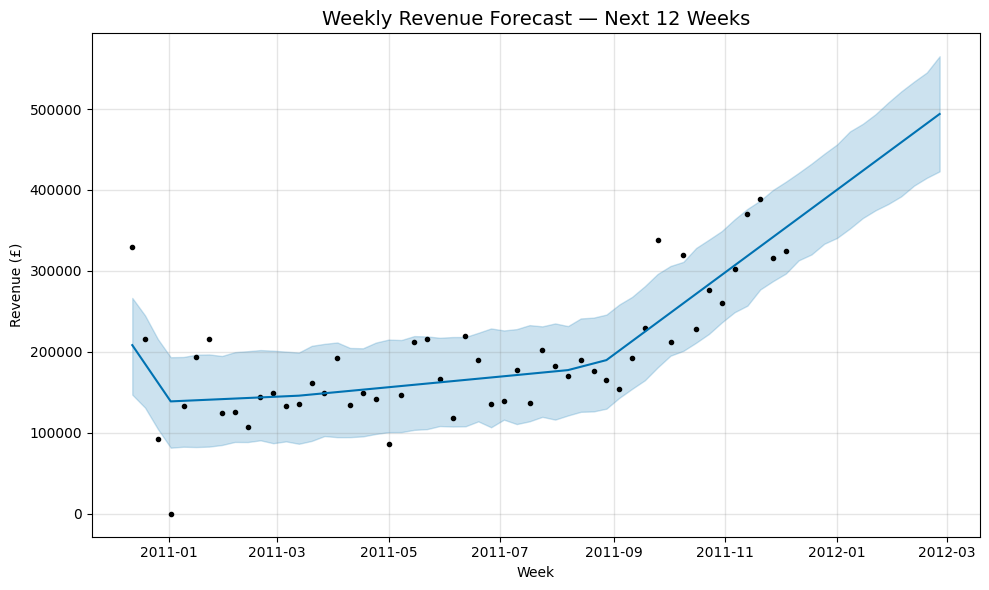

In [ ]:
fig1 = final_model.plot(forecast_final)
plt.title('Weekly Revenue Forecast — Next 12 Weeks', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=150)
plt.show()

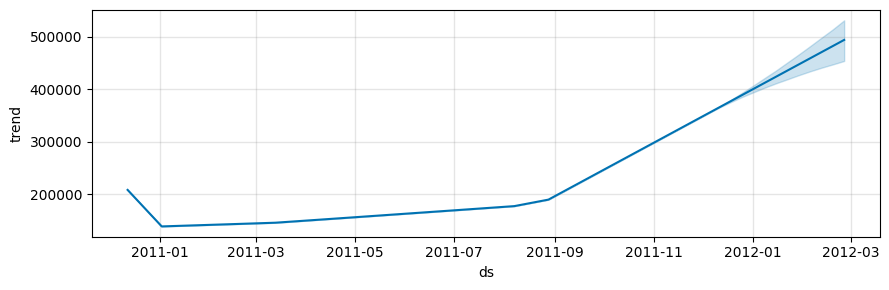

In [ ]:
fig2 = final_model.plot_components(forecast_final)
plt.tight_layout()
plt.savefig('components_plot.png', dpi=150)
plt.show()

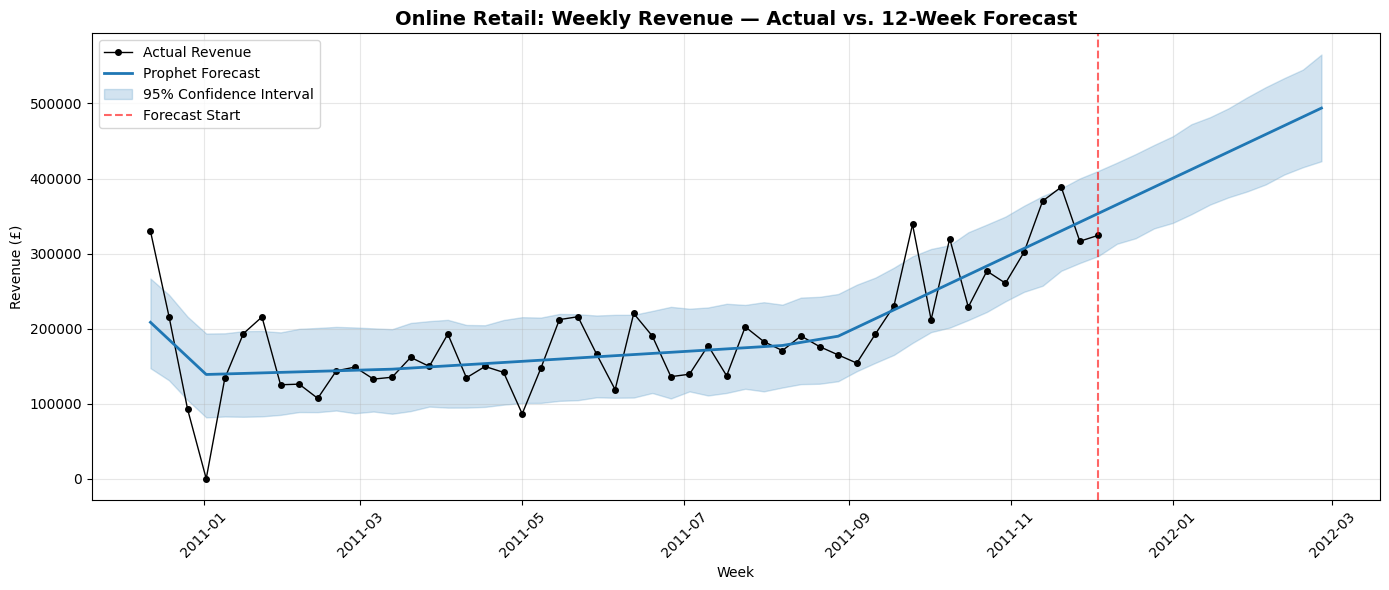

In [ ]:
plt.figure(figsize=(14, 6))

# Historical actuals (all 52 weeks)
plt.plot(df_weekly_trimmed['ds'], df_weekly_trimmed['y'],
         color='black', marker='o', markersize=4, linewidth=1, label='Actual Revenue')

# Forecast line (includes both fitted history + future)
plt.plot(forecast_final['ds'], forecast_final['yhat'],
         color='#1f77b4', linewidth=2, label='Prophet Forecast')

# Confidence interval
plt.fill_between(forecast_final['ds'], forecast_final['yhat_lower'], forecast_final['yhat_upper'],
                  color='#1f77b4', alpha=0.2, label='95% Confidence Interval')

# Mark where actual history ends / future forecast begins
plt.axvline(x=df_weekly_trimmed['ds'].max(), color='red', linestyle='--', alpha=0.6, label='Forecast Start')

plt.title('Online Retail: Weekly Revenue — Actual vs. 12-Week Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('final_forecast_chart.png', dpi=150)
plt.show()

In [ ]:
# Export the full forecast (history + future) for Power BI
export_df = forecast_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
export_df.columns = ['Date', 'Forecasted_Revenue', 'Lower_Bound', 'Upper_Bound']

# Merge in actual values where they exist (historical weeks only)
export_df = export_df.merge(df_weekly_trimmed.rename(columns={'ds':'Date','y':'Actual_Revenue'}),
                              on='Date', how='left')

export_df.to_csv('forecast_export.csv', index=False)
export_df.head()

,Date,Forecasted_Revenue,Lower_Bound,Upper_Bound,Actual_Revenue
0,2010-12-12,208399.016623,147232.822453,266693.146546,329936.81
1,2010-12-19,185228.212126,131083.566537,245013.944358,216012.20
2,2010-12-26,162057.407628,104674.148249,215798.117374,92369.30
3,2011-01-02,138888.857727,81693.367012,193455.753070,0.00
4,2011-01-09,139589.098039,82879.027507,193741.742662,133658.19
